In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')

In [3]:
print(df.shape)

(140700, 20)


In [4]:
print(df.columns.tolist())

['id', 'Name', 'Gender', 'Age', 'City', 'Working Professional or Student', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


In [5]:
print(df.dtypes)

id                                         int64
Name                                      object
Gender                                    object
Age                                      float64
City                                      object
Working Professional or Student           object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object


In [6]:
print(df.isnull().sum())

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64


In [7]:
print(df['Depression'].value_counts())

Depression
0    115133
1     25567
Name: count, dtype: int64


In [8]:
print(df['Working Professional or Student'].value_counts())

Working Professional or Student
Working Professional    112799
Student                  27901
Name: count, dtype: int64


In [9]:
workers = df[df['Working Professional or Student'] == 'Working Professional']
students = df[df['Working Professional or Student'] == 'Student']

print("Workers - Academic Pressure nulls:", workers['Academic Pressure'].isnull().sum())
print("Students - Work Pressure nulls:", students['Work Pressure'].isnull().sum())

Workers - Academic Pressure nulls: 112794
Students - Work Pressure nulls: 27898


In [10]:
df['Academic Pressure'] = df.groupby('Working Professional or Student')['Academic Pressure'].transform(lambda x: x.fillna(x.median()))
df['Study Satisfaction'] = df.groupby('Working Professional or Student')['Study Satisfaction'].transform(lambda x: x.fillna(x.median()))
df['CGPA'] = df.groupby('Working Professional or Student')['CGPA'].transform(lambda x: x.fillna(x.median()))
df['Work Pressure'] = df.groupby('Working Professional or Student')['Work Pressure'].transform(lambda x: x.fillna(x.median()))
df['Job Satisfaction'] = df.groupby('Working Professional or Student')['Job Satisfaction'].transform(lambda x: x.fillna(x.median()))

df['Dietary Habits'].fillna(df['Dietary Habits'].mode()[0], inplace=True)
df['Financial Stress'].fillna(df['Financial Stress'].median(), inplace=True)
df['Degree'].fillna(df['Degree'].mode()[0], inplace=True)

print(df.isnull().sum())

id                                           0
Name                                         0
Gender                                       0
Age                                          0
City                                         0
Working Professional or Student              0
Profession                               36630
Academic Pressure                            0
Work Pressure                                0
CGPA                                         0
Study Satisfaction                           0
Job Satisfaction                             0
Sleep Duration                               0
Dietary Habits                               0
Degree                                       0
Have you ever had suicidal thoughts ?        0
Work/Study Hours                             0
Financial Stress                             0
Family History of Mental Illness             0
Depression                                   0
dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12936\2165845121.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dietary Habits'].fillna(df['Dietary Habits'].mode()[0], inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12936\2165845121.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [11]:
print(df['Profession'].value_counts().head(35))

Profession
Teacher                   24906
Content Writer             7814
Architect                  4370
Consultant                 4229
HR Manager                 4022
Pharmacist                 3893
Doctor                     3255
Business Analyst           3161
Entrepreneur               2968
Chemist                    2967
Chef                       2862
Educational Consultant     2852
Data Scientist             2390
Researcher                 2328
Lawyer                     2212
Customer Support           2055
Marketing Manager          1976
Pilot                      1913
Travel Consultant          1860
Plumber                    1748
Sales Executive            1739
Manager                    1737
Judge                      1712
Electrician                1582
Financial Analyst          1574
Software Engineer          1510
Civil Engineer             1470
UX/UI Designer             1452
Digital Marketer           1372
Accountant                 1339
Finanancial Analyst        13

In [12]:
print(df['Profession'].nunique())

64


In [13]:
print(df[df['Profession'].isnull()]['Working Professional or Student'].value_counts())

Working Professional or Student
Student                 27867
Working Professional     8763
Name: count, dtype: int64


In [14]:
df.loc[df['Working Professional or Student'] == 'Student', 'Profession'] = 'Student'
df['Profession'].fillna('Unknown', inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12936\3232815803.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Profession'].fillna('Unknown', inplace=True)


In [15]:
profession_map = {
    # Education
    'Teacher': 'Education',
    'Educational Consultant': 'Education',
    'Researcher': 'Education',
    'Research Analyst': 'Education',

    # Creative
    'Content Writer': 'Creative',
    'Architect': 'Creative',
    'Chef': 'Creative',
    'Pilot': 'Creative',
    'UX/UI Designer': 'Creative',
    'Graphic Designer': 'Creative',
    'Digital Marketer': 'Creative',

    # Business
    'Consultant': 'Business',
    'HR Manager': 'Business',
    'Business Analyst': 'Business',
    'Entrepreneur': 'Business',
    'Marketing Manager': 'Business',
    'Manager': 'Business',
    'Sales Executive': 'Business',
    'Accountant': 'Business',
    'Financial Analyst': 'Business',
    'Finanancial Analyst': 'Business',
    'Investment Banker': 'Business',

    # Medical
    'Pharmacist': 'Medical',
    'Doctor': 'Medical',

    # Legal
    'Lawyer': 'Legal',
    'Judge': 'Legal',

    # Tech
    'Data Scientist': 'Tech',
    'Software Engineer': 'Tech',
    'Civil Engineer': 'Tech',
    'Mechanical Engineer': 'Tech',

    # Trade
    'Chemist': 'Trade',
    'Customer Support': 'Trade',
    'Plumber': 'Trade',
    'Electrician': 'Trade',

    # Travel
    'Travel Consultant': 'Travel',

    # Student & Unknown
    'Student': 'Student',
    'Unknown': 'Unknown'
}

df['Profession_Group'] = df['Profession'].map(profession_map)
df['Profession_Group'].fillna('Other', inplace=True)

print(df['Profession_Group'].value_counts())
print("---")
print("Other contains:", df[df['Profession_Group'] == 'Other']['Profession'].unique())

Profession_Group
Education    30769
Student      27905
Business     24465
Creative     20930
Unknown       8763
Trade         8352
Medical       7144
Tech          6546
Legal         3923
Travel        1860
Other           43
Name: count, dtype: int64
---
Other contains: ['Unemployed' 'Family Consultant' 'B.Com' 'BE' 'Yogesh' 'Dev' 'MBA' 'LLM'
 'BCA' 'Academic' 'Profession' 'FamilyVirar' 'City Manager' 'BBA'
 'Medical Doctor' 'Working Professional' 'MBBS' 'Patna' 'Unveil' 'B.Ed'
 'Nagpur' 'Moderate' 'M.Ed' 'Analyst' 'Pranav' 'Visakhapatnam' 'PhD'
 'Yuvraj']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12936\2697655891.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Profession_Group'].fillna('Other', inplace=True)


In [16]:
fix_map = {
    'Medical Doctor': 'Medical',
    'MBBS': 'Medical',
    'PhD': 'Education',
    'Academic': 'Education',
    'B.Ed': 'Education',
    'M.Ed': 'Education',
    'Analyst': 'Business',
}

other_mask = df['Profession_Group'] == 'Other'

df.loc[other_mask, 'Profession_Group'] = df.loc[other_mask, 'Profession'].map(fix_map)

df['Profession_Group'].fillna('Other', inplace=True)

print(df['Profession_Group'].value_counts())

Profession_Group
Education    30778
Student      27905
Business     24466
Creative     20930
Unknown       8763
Trade         8352
Medical       7146
Tech          6546
Legal         3923
Travel        1860
Other           31
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12936\513572098.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Profession_Group'].fillna('Other', inplace=True)


In [17]:
print(df.head(10).to_string())

   id       Name  Gender   Age           City Working Professional or Student           Profession  Academic Pressure  Work Pressure   CGPA  Study Satisfaction  Job Satisfaction     Sleep Duration Dietary Habits   Degree Have you ever had suicidal thoughts ?  Work/Study Hours  Financial Stress Family History of Mental Illness  Depression Profession_Group
0   0   Aaradhya  Female  49.0       Ludhiana            Working Professional                 Chef                4.0            5.0  8.125                 3.0               2.0  More than 8 hours        Healthy      BHM                                    No               1.0               2.0                               No           0         Creative
1   1      Vivan    Male  26.0       Varanasi            Working Professional              Teacher                4.0            4.0  8.125                 3.0               3.0  Less than 5 hours      Unhealthy      LLB                                   Yes               7.0          

In [18]:
print(df['Degree'].nunique())
print(df['Degree'].value_counts().head(10))

115
Degree
Class 12    14731
B.Ed        11691
B.Arch       8742
B.Com        8113
B.Pharm      5856
BCA          5739
M.Ed         5668
MCA          5234
BBA          5030
BSc          5027
Name: count, dtype: int64


In [19]:
test_df = pd.read_csv('test.csv')
print(test_df.shape)

(93800, 19)


In [20]:
from sklearn.preprocessing import OrdinalEncoder

In [21]:
print("Sleep Duration unique values:")
print(df['Sleep Duration'].unique())
print("--------------")
print("Dietary Habits unique values:")
print(df['Dietary Habits'].unique())

Sleep Duration unique values:
['More than 8 hours' 'Less than 5 hours' '5-6 hours' '7-8 hours'
 'Sleep_Duration' '1-2 hours' '6-8 hours' '4-6 hours' '6-7 hours'
 '10-11 hours' '8-9 hours' '40-45 hours' '9-11 hours' '2-3 hours'
 '3-4 hours' 'Moderate' '55-66 hours' '4-5 hours' '9-6 hours' '1-3 hours'
 'Indore' '45' '1-6 hours' '35-36 hours' '8 hours' 'No' '10-6 hours'
 'than 5 hours' '49 hours' 'Unhealthy' 'Work_Study_Hours' '3-6 hours'
 '45-48 hours' '9-5' 'Pune' '9-5 hours']
--------------
Dietary Habits unique values:
['Healthy' 'Unhealthy' 'Moderate' 'Yes' 'Pratham' 'BSc' 'Gender' '3'
 'More Healthy' 'Less than Healthy' 'Mihir' '1.0' 'Hormonal' 'Electrician'
 'No Healthy' 'Less Healthy' 'M.Tech' 'Vegas' 'No' 'Male' 'Indoor'
 'Class 12' '2']


In [22]:
valid_sleep = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
valid_diet = ['Healthy', 'Moderate', 'Unhealthy']


df['Sleep Duration'] = df['Sleep Duration'].where(
    df['Sleep Duration'].isin(valid_sleep), other=None)
test_df['Sleep Duration'] = test_df['Sleep Duration'].where(
    test_df['Sleep Duration'].isin(valid_sleep), other=None)

df['Dietary Habits'] = df['Dietary Habits'].where(
    df['Dietary Habits'].isin(valid_diet), other=None)
test_df['Dietary Habits'] = test_df['Dietary Habits'].where(
    test_df['Dietary Habits'].isin(valid_diet), other=None)

df['Sleep Duration'].fillna(df['Sleep Duration'].mode()[0], inplace=True)
test_df['Sleep Duration'].fillna(df['Sleep Duration'].mode()[0], inplace=True)

df['Dietary Habits'].fillna(df['Dietary Habits'].mode()[0], inplace=True)
test_df['Dietary Habits'].fillna(df['Dietary Habits'].mode()[0], inplace=True)

print("Sleep Duration unique:", df['Sleep Duration'].unique())
print("Dietary Habits unique:", df['Dietary Habits'].unique())

Sleep Duration unique: ['More than 8 hours' 'Less than 5 hours' '5-6 hours' '7-8 hours']
Dietary Habits unique: ['Healthy' 'Unhealthy' 'Moderate']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12936\3564495446.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Duration'].fillna(df['Sleep Duration'].mode()[0], inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12936\3564495446.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

def preprocess(train, test):
    train = train.copy()
    test = test.copy()
    
    # Profession_Group
    def map_profession(df):
        df.loc[df['Working Professional or Student'] == 'Student', 'Profession'] = 'Student'
        df['Profession'] = df['Profession'].fillna('Unknown')
        profession_map = {
            'Teacher': 'Education', 'Educational Consultant': 'Education',
            'Researcher': 'Education', 'Research Analyst': 'Education',
            'PhD': 'Education', 'Academic': 'Education',
            'B.Ed': 'Education', 'M.Ed': 'Education',
            'Content Writer': 'Creative', 'Architect': 'Creative',
            'Chef': 'Creative', 'Pilot': 'Creative',
            'UX/UI Designer': 'Creative', 'Graphic Designer': 'Creative',
            'Digital Marketer': 'Creative',
            'Consultant': 'Business', 'HR Manager': 'Business',
            'Business Analyst': 'Business', 'Entrepreneur': 'Business',
            'Marketing Manager': 'Business', 'Manager': 'Business',
            'Sales Executive': 'Business', 'Accountant': 'Business',
            'Financial Analyst': 'Business', 'Finanancial Analyst': 'Business',
            'Investment Banker': 'Business', 'Analyst': 'Business',
            'Medical Doctor': 'Medical', 'MBBS': 'Medical',
            'Pharmacist': 'Medical', 'Doctor': 'Medical',
            'Lawyer': 'Legal', 'Judge': 'Legal',
            'Data Scientist': 'Tech', 'Software Engineer': 'Tech',
            'Civil Engineer': 'Tech', 'Mechanical Engineer': 'Tech',
            'Chemist': 'Trade', 'Customer Support': 'Trade',
            'Plumber': 'Trade', 'Electrician': 'Trade',
            'Travel Consultant': 'Travel',
            'Student': 'Student', 'Unknown': 'Unknown'
        }
        df['Profession_Group'] = df['Profession'].map(profession_map)
        df['Profession_Group'] = df['Profession_Group'].fillna('Other')
        return df

    train = map_profession(train)
    test = map_profession(test)

    # Missing values numerical
    for col in ['Academic Pressure', 'Work Pressure', 'CGPA',
                'Study Satisfaction', 'Job Satisfaction']:
        medians = train.groupby('Working Professional or Student')[col].median()
        train[col] = train[col].fillna(train['Working Professional or Student'].map(medians))
        test[col] = test[col].fillna(test['Working Professional or Student'].map(medians))

    # Clean dirty values
    valid_sleep = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
    valid_diet = ['Healthy', 'Moderate', 'Unhealthy']

    train['Sleep Duration'] = train['Sleep Duration'].where(train['Sleep Duration'].isin(valid_sleep))
    test['Sleep Duration'] = test['Sleep Duration'].where(test['Sleep Duration'].isin(valid_sleep))
    train['Dietary Habits'] = train['Dietary Habits'].where(train['Dietary Habits'].isin(valid_diet))
    test['Dietary Habits'] = test['Dietary Habits'].where(test['Dietary Habits'].isin(valid_diet))

    for col in ['Sleep Duration', 'Dietary Habits', 'Degree', 'Financial Stress']:
        mode_val = train[col].mode()[0]
        train[col] = train[col].fillna(mode_val)
        test[col] = test[col].fillna(mode_val)

    # Drop
    drop_cols = ['id', 'Name', 'Profession', 'City']
    train = train.drop(columns=drop_cols)
    test = test.drop(columns=[c for c in drop_cols if c in test.columns])

    # Binary Encoding
    binary_map = {
        'Gender': {'Male': 0, 'Female': 1},
        'Working Professional or Student': {'Working Professional': 1, 'Student': 0},
        'Have you ever had suicidal thoughts ?': {'Yes': 1, 'No': 0},
        'Family History of Mental Illness': {'Yes': 1, 'No': 0}
    }
    for col, mapping in binary_map.items():
        train[col] = train[col].map(mapping)
        test[col] = test[col].map(mapping)

    # Ordinal Encoding
    sleep_order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
    diet_order = ['Unhealthy', 'Moderate', 'Healthy']
    ordinal_enc = OrdinalEncoder(categories=[sleep_order, diet_order])
    train[['Sleep Duration', 'Dietary Habits']] = ordinal_enc.fit_transform(
        train[['Sleep Duration', 'Dietary Habits']])
    test[['Sleep Duration', 'Dietary Habits']] = ordinal_enc.transform(
        test[['Sleep Duration', 'Dietary Habits']])

    # One-Hot Profession_Group
    train = pd.get_dummies(train, columns=['Profession_Group'], drop_first=False)
    test = pd.get_dummies(test, columns=['Profession_Group'], drop_first=False)
    test = test.reindex(columns=[c for c in train.columns if c != 'Depression'], fill_value=0)

    # Target Encoding Degree
    degree_target_map = train.groupby('Degree')['Depression'].mean()
    train['Degree'] = train['Degree'].map(degree_target_map)
    test['Degree'] = test['Degree'].map(degree_target_map)
    test['Degree'] = test['Degree'].fillna(train['Depression'].mean())

    return train, test

train_df, test_df = preprocess(train_df, test_df)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.isnull().sum().sum())

Train shape: (140700, 27)
Test shape: (93800, 26)
0


In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

X = train_df.drop(columns=['Depression'])
y = train_df['Depression']

# Dummy Classifier
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy, X, y, cv=5, scoring='f1')
print(f"Dummy F1: {dummy_scores.mean():.4f} (+/- {dummy_scores.std():.4f})")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X, y, cv=5, scoring='f1')
print(f"Logistic Regression F1: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")

Dummy F1: 0.0000 (+/- 0.0000)
Logistic Regression F1: 0.8254 (+/- 0.0038)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    print(f"{name} F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

Random Forest F1: 0.8189 (+/- 0.0026)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 20454, number of negative: 92106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 339
[LightGBM] [Info] Number of data points in the train set: 112560, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.181716 -> initscore=-1.504762
[LightGBM] [Info] Start training from score -1.504762
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 20454, number of negative: 92106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memo

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 25567, number of negative: 115133
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005993 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 341
[LightGBM] [Info] Number of data points in the train set: 140700, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.181713 -> initscore=-1.504786
[LightGBM] [Info] Start training from score -1.504786


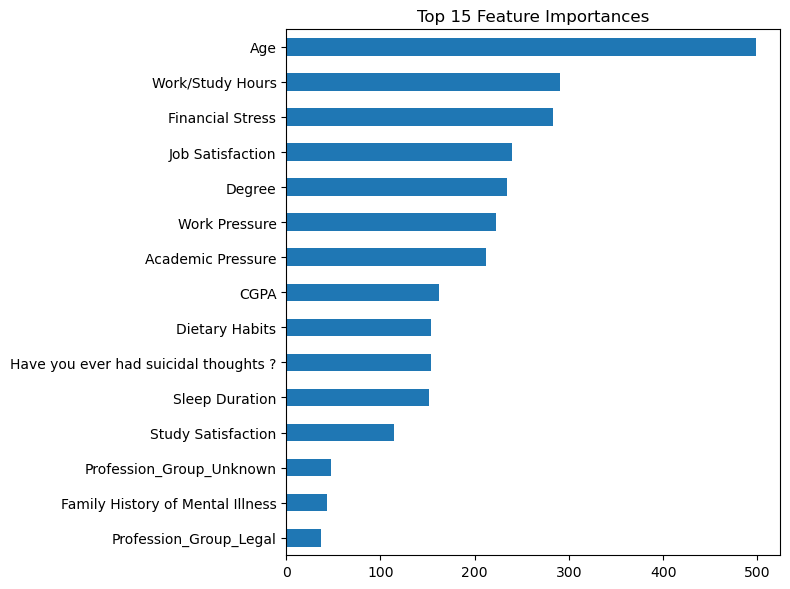

In [31]:
import matplotlib.pyplot as plt


lgbm = LGBMClassifier(random_state=42, n_jobs=-1)
lgbm.fit(X, y)

feat_imp = pd.Series(lgbm.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=True).tail(15).plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [32]:
def add_features(df):
    df = df.copy()
    

    df['Total_Stress'] = (df['Work Pressure'] + 
                          df['Financial Stress'] + 
                          df['Academic Pressure']) / 3
    
     
    df['Total_Satisfaction'] = (df['Job Satisfaction'] + 
                                 df['Study Satisfaction']) / 2
    
   
    df['Stress_Satisfaction_Ratio'] = (df['Total_Stress'] + 1) / (df['Total_Satisfaction'] + 1)
    
   
    df['WorkPressure_Sleep'] = df['Work Pressure'] * df['Sleep Duration']
    

    df['WorkHours_Sleep'] = df['Work/Study Hours'] * df['Sleep Duration']
    
    return df

X_new = add_features(train_df.drop(columns=['Depression']))
y = train_df['Depression']

lgbm = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
scores = cross_val_score(lgbm, X_new, y, cv=5, scoring='f1')
print(f"LightGBM + New Features F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

LightGBM + New Features F1: 0.8287 (+/- 0.0020)


In [33]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_new, y, cv=5, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best F1: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best F1: 0.8303
Best params: {'n_estimators': 269, 'learning_rate': 0.06757892963638702, 'num_leaves': 117, 'max_depth': 5, 'min_child_samples': 15, 'subsample': 0.8241814582298154, 'colsample_bytree': 0.5185374791464193}


In [ ]:
X_test_new = add_features(test_df)

final_model = LGBMClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
final_model.fit(X_new, y)


predictions = final_model.predict(X_test_new)


sample_submission = pd.read_csv('sample_submission.csv')
sample_submission['Depression'] = predictions
sample_submission.to_csv('submission.csv', index=False)

print("Submission shape:", sample_submission.shape)
print("Depression distribution:")
print(sample_submission['Depression'].value_counts())

Submission shape: (93800, 2)
Depression distribution:
Depression
0    77289
1    16511
Name: count, dtype: int64


In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = train_df.drop(columns=['Depression'])
y = train_df['Depression']

X_new = add_features(X)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgbm = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
scores = cross_val_score(lgbm, X_new, y, cv=skf, scoring='f1')
print(f"Stratified KFold F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

Stratified KFold F1: 0.8299 (+/- 0.0041)


In [ ]:
from sklearn.metrics import f1_score

lgbm = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)

from sklearn.model_selection import cross_val_predict
y_proba = cross_val_predict(lgbm, X_new, y, cv=skf, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for thresh in thresholds:
    y_pred = (y_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y, y_pred))

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Default threshold (0.5) F1: {f1_score(y, (y_proba >= 0.5).astype(int)):.4f}")
print(f"Best threshold: {best_thresh:.2f}")
print(f"Best F1: {best_f1:.4f}")

Default threshold (0.5) F1: 0.8299
Best threshold: 0.38
Best F1: 0.8338


In [38]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }
    threshold = trial.suggest_float('threshold', 0.3, 0.5)

    model = LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
    y_proba = cross_val_predict(model, X_new, y, cv=skf, method='predict_proba')[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return f1_score(y, y_pred)

study2 = optuna.create_study(direction='maximize')
study2.optimize(objective, n_trials=100)

print(f"Best F1: {study2.best_value:.4f}")
print(f"Best params: {study2.best_params}")

Best F1: 0.8342
Best params: {'n_estimators': 650, 'learning_rate': 0.01824333204555325, 'num_leaves': 113, 'max_depth': 7, 'min_child_samples': 49, 'subsample': 0.9902848323830832, 'colsample_bytree': 0.5036103055460437, 'threshold': 0.4004749890589696}


In [39]:
best_params = study2.best_params.copy()
best_threshold = best_params.pop('threshold')

final_model = LGBMClassifier(**best_params, random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_new, y)

X_test_new = add_features(test_df)
y_proba_test = final_model.predict_proba(X_test_new)[:, 1]
predictions = (y_proba_test >= best_threshold).astype(int)

sample_submission = pd.read_csv('sample_submission.csv')
sample_submission['Depression'] = predictions
sample_submission.to_csv('submission_v2.csv', index=False)

print("Depression distribution:")
print(sample_submission['Depression'].value_counts())

Depression distribution:
Depression
0    75899
1    17901
Name: count, dtype: int64


In [ ]:
best_params_v1 = {k: v for k, v in study2.best_params.items() if k != 'threshold'}

final_model = LGBMClassifier(**best_params_v1, random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_new, y)

X_test_new = add_features(test_df)
y_proba_test = final_model.predict_proba(X_test_new)[:, 1]

confidence_threshold_high = 0.85  
confidence_threshold_low = 0.15   

confident_mask = (y_proba_test >= confidence_threshold_high) | (y_proba_test <= confidence_threshold_low)
pseudo_labels = (y_proba_test >= 0.5).astype(int)

print(f"Total test samples: {len(y_proba_test)}")
print(f"Confident predictions: {confident_mask.sum()}")
print(f"Confident positive (depressed): {(y_proba_test[confident_mask] >= 0.5).sum()}")
print(f"Confident negative: {(y_proba_test[confident_mask] < 0.5).sum()}")

Total test samples: 93800
Confident predictions: 80610
Confident positive (depressed): 10129
Confident negative: 70481


In [ ]:

X_test_confident = X_test_new[confident_mask].copy()
y_pseudo = pseudo_labels[confident_mask]

X_combined = pd.concat([X_new, X_test_confident], ignore_index=True)
y_combined = pd.concat([y, pd.Series(y_pseudo)], ignore_index=True)

print(f"Original training size: {len(X_new)}")
print(f"New training size: {len(X_combined)}")
print(f"New class distribution:")
print(y_combined.value_counts())

final_model_pseudo = LGBMClassifier(**best_params_v1, random_state=42, n_jobs=-1, verbose=-1)
final_model_pseudo.fit(X_combined, y_combined)

y_proba_final = final_model_pseudo.predict_proba(X_test_new)[:, 1]
predictions_final = (y_proba_final >= 0.5).astype(int)

sample_submission = pd.read_csv('sample_submission.csv')
sample_submission['Depression'] = predictions_final
sample_submission.to_csv('submission_v3.csv', index=False)

print(f"\nFinal predictions distribution:")
print(sample_submission['Depression'].value_counts())

Original training size: 140700
New training size: 221310
New class distribution:
0    185614
1     35696
Name: count, dtype: int64

Final predictions distribution:
Depression
0    77342
1    16458
Name: count, dtype: int64
